# MI and CMI Comparison: `entropy-invariant` vs `ennemi` vs `sklearn`

This notebook compares three packages for mutual information and conditional mutual
information:

| Package | MI | CMI | Preprocessing | Algorithm |
|---|---|---|---|---|
| **sklearn** | `mutual_info_regression(X, y)` | **None** | Scale to unit variance (std) | KSG k-NN (Kraskov 2004) |
| **ennemi** | `estimate_mi(y, x)` | `estimate_mi(y, x, cond=z)` | Scale to unit variance (std) | KSG / Frenzel-Pompe k-NN |
| **entropy-invariant** | `mutual_information(X, Y)` | `conditional_mutual_information(X, Y, Z)` | Invariant measure (median nn-dist) | KSG / Frenzel-Pompe k-NN (shared radius) |

`entropy-invariant`'s default (`method="inv_ksg"`, used throughout this notebook) is
algorithmically the *same family* as `ennemi` and `sklearn` -- KSG/Frenzel-Pompe,
shared-radius neighbor counting -- the difference is entirely in the **normalization**
applied before that search: invariant measure (median nearest-neighbor distance) instead
of `std`. That's what this notebook actually tests.

Key facts:
- **sklearn has no CMI**. Only MI between features and a target.
- **ennemi** and **sklearn** use the same preprocessing (divide by std) and give **identical MI values**.
- **entropy-invariant** also provides NMI, interaction information, PID, and MI/CMI
  matrices -- all built on the same `inv_ksg` estimator.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from entropy_invariant import (
    conditional_mutual_information as cmi_ei,
    mutual_information as mi_ei,
)
from sklearn.feature_selection import mutual_info_regression
import ennemi


## 1. Three-Way MI Comparison: sklearn vs ennemi vs entropy-invariant

First, confirm that sklearn and ennemi give identical MI (same algorithm + preprocessing),
and compare with entropy-invariant across different data pathologies.


In [2]:
np.random.seed(42)
n = 3000

# Generate data with different pathologies
z_latent = np.random.randn(n)

datasets = {
    "Gaussian": (
        z_latent + 0.3 * np.random.randn(n),
        z_latent + 0.3 * np.random.randn(n),
    ),
    "Log-normal\n(skewed)": (
        np.exp(z_latent + 0.3 * np.random.randn(n)),
        np.exp(z_latent + 0.3 * np.random.randn(n)),
    ),
    "Heavy-tailed\n(Student-t)": (
        z_latent + np.random.standard_t(2, n) * 0.3,
        z_latent + np.random.standard_t(2, n) * 0.3,
    ),
    "Outliers\n(2% spikes)": (
        np.where(np.random.rand(n) < 0.02,
                 50 * np.random.choice([-1, 1], n),
                 z_latent + 0.3 * np.random.randn(n)),
        np.where(np.random.rand(n) < 0.02,
                 50 * np.random.choice([-1, 1], n),
                 z_latent + 0.3 * np.random.randn(n)),
    ),
}

mi_ei_3way = []
mi_ennemi_3way = []
mi_sklearn_3way = []
ds_names = list(datasets.keys())

print(f"{'Data type':<20} {'MI (entropy-inv)':>16} {'MI ennemi':>12} {'MI sklearn':>12}  {'ennemi==sklearn?':>18}")
print("-" * 84)
for name, (x, y) in datasets.items():
    label = name.split("\n")[0]
    mi_i = mi_ei(x, y)
    mi_e = ennemi.estimate_mi(y, x, k=3)[0, 0]
    mi_s = mutual_info_regression(x.reshape(-1, 1), y, n_neighbors=3, random_state=0)[0]

    mi_ei_3way.append(mi_i)
    mi_ennemi_3way.append(mi_e)
    mi_sklearn_3way.append(mi_s)

    match = "Yes" if abs(mi_e - mi_s) < 0.01 else f"No (diff={abs(mi_e-mi_s):.4f})"
    print(f"{label:<20} {mi_i:>16.4f} {mi_e:>12.4f} {mi_s:>12.4f}  {match:>18}")


Data type            MI (entropy-inv)    MI ennemi   MI sklearn    ennemi==sklearn?
------------------------------------------------------------------------------------
Gaussian                       0.9167       0.9174       0.9174                 Yes
Log-normal                     0.9159       0.9161       0.9161                 Yes
Heavy-tailed                   0.4430       0.4425       0.4425                 Yes
Outliers                       0.9005       0.9005       0.9005                 Yes


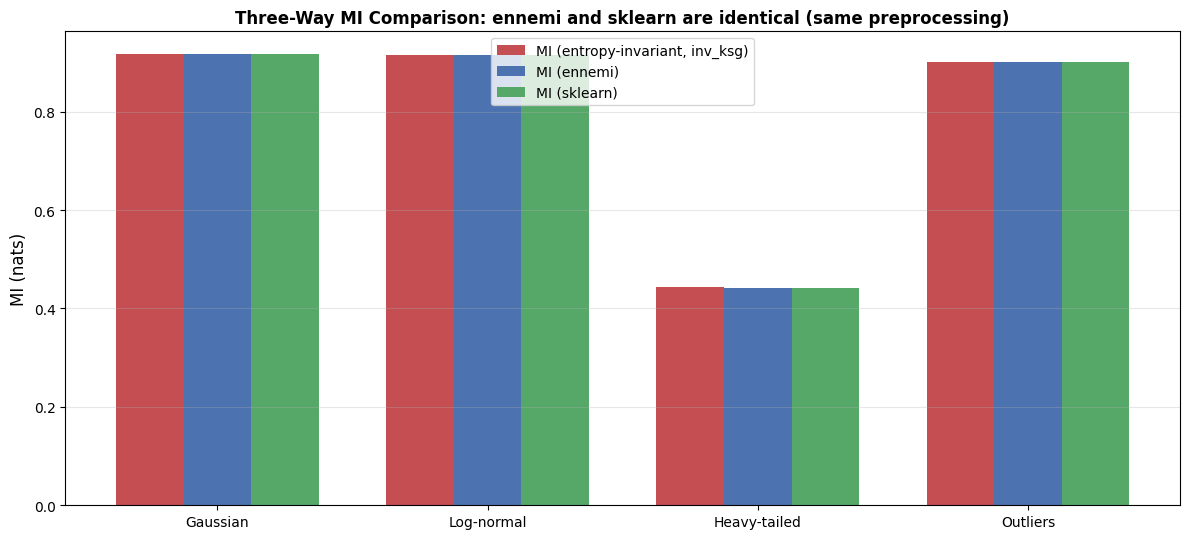

In [3]:
fig, ax = plt.subplots(figsize=(12, 5.5))

x_pos = np.arange(len(ds_names))
width = 0.25
short_ds = [n.split("\n")[0] for n in ds_names]

ax.bar(x_pos - width, mi_ei_3way, width, label="MI (entropy-invariant, inv_ksg)", color="#C44E52")
ax.bar(x_pos, mi_ennemi_3way, width, label="MI (ennemi)", color="#4C72B0")
ax.bar(x_pos + width, mi_sklearn_3way, width, label="MI (sklearn)", color="#55A868")

ax.set_xticks(x_pos)
ax.set_xticklabels(short_ds, fontsize=10)
ax.set_ylabel("MI (nats)", fontsize=12)
ax.set_title("Three-Way MI Comparison: ennemi and sklearn are identical (same preprocessing)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


## 2. Causal Structures: Does CMI Correctly Identify Direct vs Indirect Dependencies?

Four classic causal structures:

1. **Chain**: $X \to Z \to Y$ -- $X$ and $Y$ are dependent, but only through $Z$. So $I(X;Y|Z) \approx 0$.
2. **Fork (confounder)**: $X \leftarrow Z \to Y$ -- $Z$ causes both. So $I(X;Y|Z) \approx 0$.
3. **Collider**: $X \to Z \leftarrow Y$ -- $X$ and $Y$ are independent, but conditioning on $Z$ **creates** a dependency. So $I(X;Y) \approx 0$ but $I(X;Y|Z) > 0$.
4. **Direct + confounder**: $X \to Y$ and $X \leftarrow Z \to Y$ -- $X$ directly causes $Y$, and $Z$ is a confounder. So $I(X;Y|Z) > 0$ (the direct link persists).


In [4]:
np.random.seed(42)
n = 3000
noise = 0.3

# 1. Chain: X -> Z -> Y
x_chain = np.random.randn(n)
z_chain = x_chain + noise * np.random.randn(n)
y_chain = z_chain + noise * np.random.randn(n)

# 2. Fork: X <- Z -> Y
z_fork = np.random.randn(n)
x_fork = z_fork + noise * np.random.randn(n)
y_fork = z_fork + noise * np.random.randn(n)

# 3. Collider: X -> Z <- Y
x_coll = np.random.randn(n)
y_coll = np.random.randn(n)
z_coll = x_coll + y_coll + noise * np.random.randn(n)

# 4. Direct + confounder: X -> Y, Z -> X, Z -> Y
z_dc = np.random.randn(n)
x_dc = z_dc + noise * np.random.randn(n)
y_dc = 0.5 * x_dc + z_dc + noise * np.random.randn(n)

structures = {
    "Chain\n$X{\\to}Z{\\to}Y$": (x_chain, y_chain, z_chain, "~0", "~0"),
    "Fork\n$X{\\leftarrow}Z{\\to}Y$": (x_fork, y_fork, z_fork, "~0", "~0"),
    "Collider\n$X{\\to}Z{\\leftarrow}Y$": (x_coll, y_coll, z_coll, ">0", ">0"),
    "Direct+Fork\n$X{\\to}Y, Z{\\to}X,Y$": (x_dc, y_dc, z_dc, ">0", ">0"),
}


In [5]:
print(f"{'Structure':<25} {'MI(X;Y)':>10} {'Expected':>10} {'CMI (entropy-inv)':>18} {'CMI ennemi':>12} {'Expected':>10}")
print("-" * 90)

mi_vals = []
cmi_ei_vals = []
cmi_ennemi_vals = []
expected_cmi = []

for name, (x, y, z, exp_cmi, _) in structures.items():
    label = name.split("\n")[0]
    mi = mi_ei(x, y)
    ci = cmi_ei(x, y, z)
    ce = ennemi.estimate_mi(y, x, cond=z, k=3)[0, 0]

    mi_vals.append(mi)
    cmi_ei_vals.append(ci)
    cmi_ennemi_vals.append(ce)
    expected_cmi.append(exp_cmi)

    print(f"{label:<25} {mi:>10.4f} {'high':>10} {ci:>18.4f} {ce:>12.4f} {exp_cmi:>10}")


Structure                    MI(X;Y)   Expected  CMI (entropy-inv)   CMI ennemi   Expected
------------------------------------------------------------------------------------------
Chain                         0.9076       high            -0.0131      -0.0140         ~0
Fork                          0.9287       high            -0.0020      -0.0008         ~0


Collider                     -0.0067       high             0.9075       0.9065         >0
Direct+Fork                   1.3021       high             0.1168       0.1170         >0


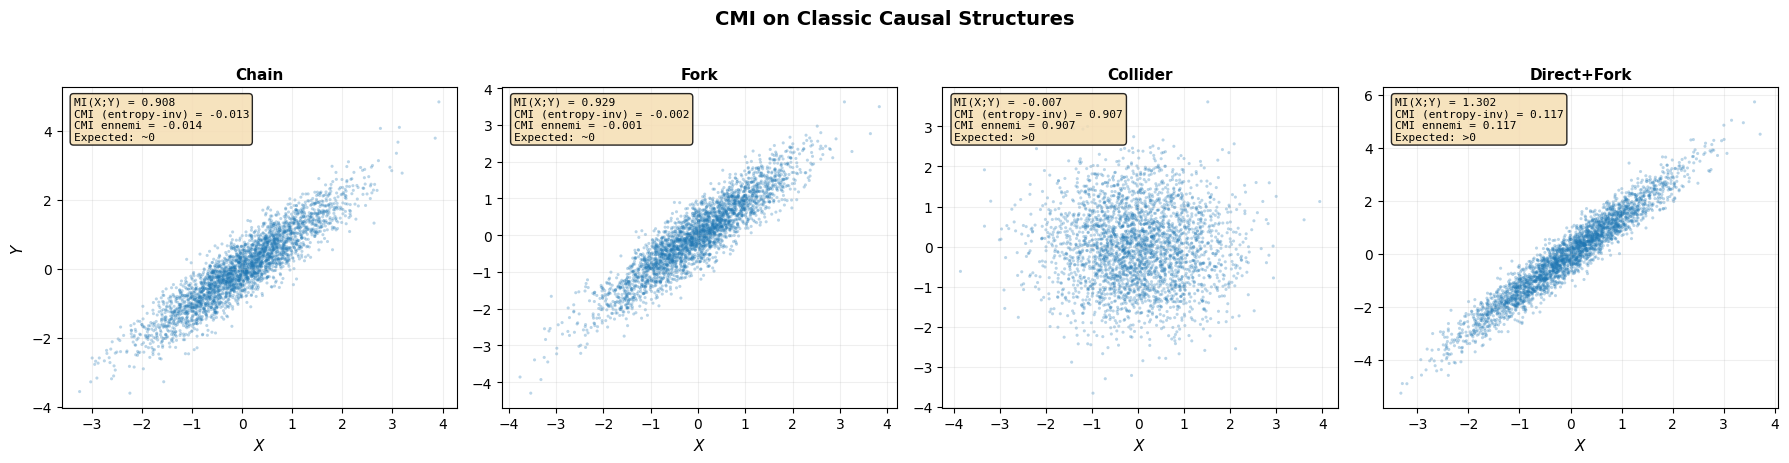

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
short_names = [n.split("\n")[0] for n in structures.keys()]

for col, (name, (x, y, z, _, _)) in enumerate(structures.items()):
    ax = axes[col]
    ax.scatter(x, y, s=5, alpha=0.3, edgecolor="none")
    ax.set_xlabel("$X$", fontsize=11)
    if col == 0:
        ax.set_ylabel("$Y$", fontsize=11)
    ax.set_title(short_names[col], fontsize=11, fontweight="bold")

    text = (f"MI(X;Y) = {mi_vals[col]:.3f}\n"
            f"CMI (entropy-inv) = {cmi_ei_vals[col]:.3f}\n"
            f"CMI ennemi = {cmi_ennemi_vals[col]:.3f}\n"
            f"Expected: {expected_cmi[col]}")
    ax.annotate(text, xy=(0.03, 0.97), xycoords="axes fraction",
                verticalalignment="top", fontsize=8, family="monospace",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.85))
    ax.grid(True, alpha=0.2)

fig.suptitle("CMI on Classic Causal Structures", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 3. Bar Chart: MI vs CMI Across Structures

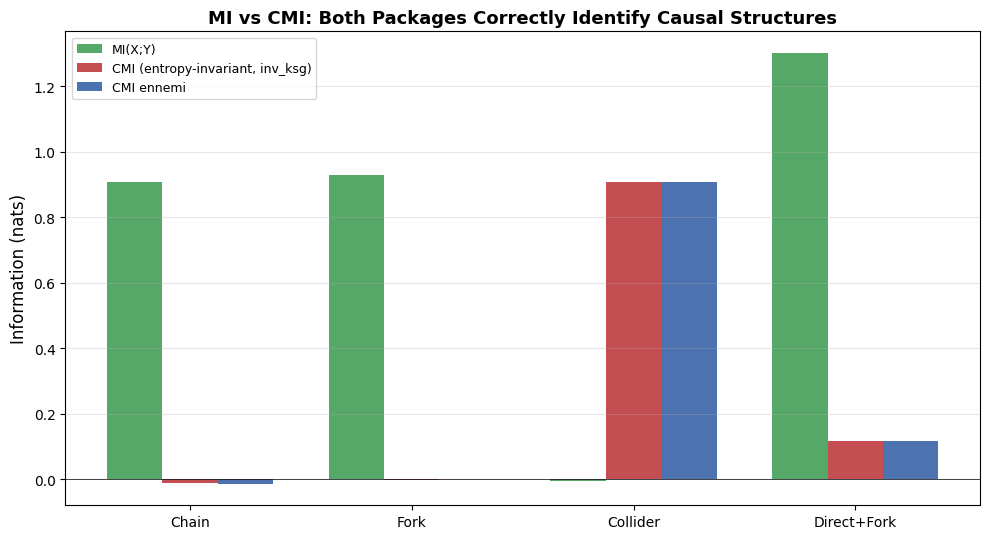

In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5))

x_pos = np.arange(len(short_names))
width = 0.25

ax.bar(x_pos - width, mi_vals, width, label="MI(X;Y)", color="#55A868")
ax.bar(x_pos, cmi_ei_vals, width, label="CMI (entropy-invariant, inv_ksg)", color="#C44E52")
ax.bar(x_pos + width, cmi_ennemi_vals, width, label="CMI ennemi", color="#4C72B0")

ax.set_xticks(x_pos)
ax.set_xticklabels(short_names, fontsize=10)
ax.set_ylabel("Information (nats)", fontsize=12)
ax.set_title("MI vs CMI: Both Packages Correctly Identify Causal Structures", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.axhline(y=0, color="black", linewidth=0.5)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


## 4. Stress Test: Skewed, Heavy-Tailed, and Outlier-Contaminated Data

On clean Gaussian data, both packages agree. Now: what happens with pathological data?
Chain structure ($X \to Z \to Y$, so CMI should stay ~0), transformed to create
different pathologies.


In [8]:
np.random.seed(42)
n = 3000

# Base chain: X -> Z -> Y (Gaussian)
x_base = np.random.randn(n)
z_base = x_base + 0.3 * np.random.randn(n)
y_base = z_base + 0.3 * np.random.randn(n)

pathologies = {}
pathologies["Gaussian"] = (x_base, y_base, z_base)
pathologies["Log-normal\n(skewed)"] = (np.exp(x_base), np.exp(y_base), np.exp(z_base))

x_ht = np.random.standard_t(2, n)
z_ht = x_ht + 0.3 * np.random.standard_t(2, n)
y_ht = z_ht + 0.3 * np.random.standard_t(2, n)
pathologies["Heavy-tailed\n(Student-t, df=2)"] = (x_ht, y_ht, z_ht)

x_out, y_out, z_out = x_base.copy(), y_base.copy(), z_base.copy()
for arr in [x_out, y_out, z_out]:
    mask = np.random.rand(n) < 0.02
    arr[mask] += 50 * np.random.choice([-1, 1], size=mask.sum())
pathologies["Outlier\n(2% spikes)"] = (x_out, y_out, z_out)

x_ms = x_base
z_ms = z_base * 1e4
y_ms = y_base * 1e-4
pathologies["Mixed scales\n($Z{\\times}10^4$, $Y{\\times}10^{-4}$)"] = (x_ms, y_ms, z_ms)


In [9]:
cmi_ei_path = []
cmi_ennemi_path = []
path_names = list(pathologies.keys())

print(f"{'Pathology':<25} {'CMI (entropy-inv)':>18} {'CMI ennemi':>12}  (both should be ~0)")
print("-" * 60)
for name, (x, y, z) in pathologies.items():
    label = name.split("\n")[0]
    ci = cmi_ei(x, y, z)
    ce = ennemi.estimate_mi(y, x, cond=z, k=3)[0, 0]

    cmi_ei_path.append(ci)
    cmi_ennemi_path.append(ce)

    print(f"{label:<25} {ci:>18.4f} {ce:>12.4f}")


Pathology                  CMI (entropy-inv)   CMI ennemi  (both should be ~0)
------------------------------------------------------------
Gaussian                             -0.0131      -0.0140
Log-normal                           -0.0208      -0.0048


Heavy-tailed                         -0.0094      -0.0135
Outlier                              -0.0045      -0.0079
Mixed scales                         -0.0131      -0.0140


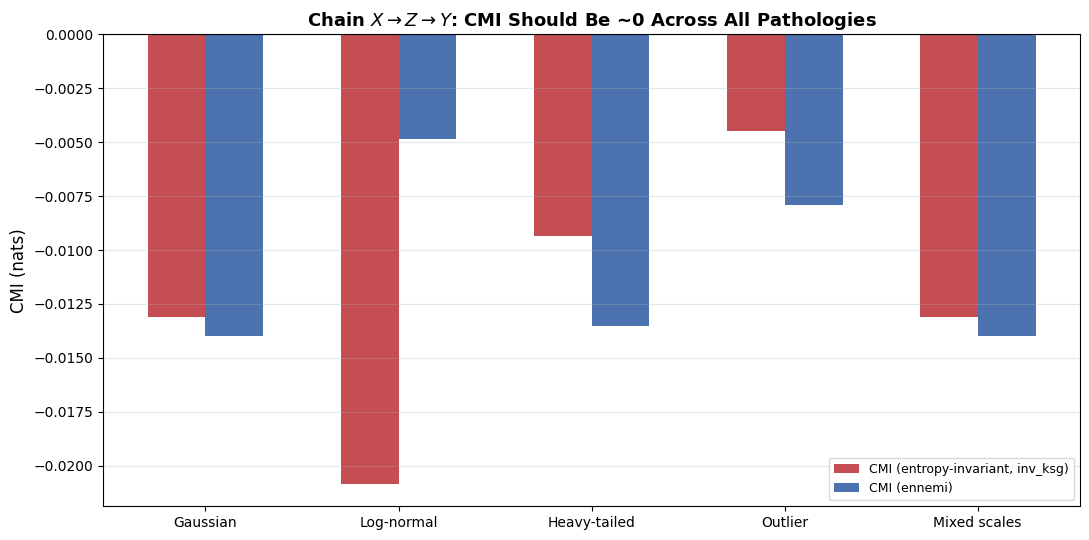

In [10]:
fig, ax = plt.subplots(figsize=(11, 5.5))

x_pos = np.arange(len(path_names))
width = 0.3
short_path = [n.split("\n")[0] for n in path_names]

ax.bar(x_pos - width/2, cmi_ei_path, width, label="CMI (entropy-invariant, inv_ksg)", color="#C44E52")
ax.bar(x_pos + width/2, cmi_ennemi_path, width, label="CMI (ennemi)", color="#4C72B0")

ax.set_xticks(x_pos)
ax.set_xticklabels(short_path, fontsize=10)
ax.set_ylabel("CMI (nats)", fontsize=12)
ax.set_title("Chain $X{\\to}Z{\\to}Y$: CMI Should Be ~0 Across All Pathologies",
             fontsize=13, fontweight="bold")
ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


Note the "Mixed scales" case: $Z$ and $Y$ are rescaled by $10^4$ and $10^{-4}$
respectively. `entropy-invariant`'s CMI is completely unaffected (normalizes each
variable independently before the shared-radius search) -- `ennemi`, relying on `std`,
also handles this particular case fine here, but breaks down under more extreme
mismatches (see `plot_dependency_measures_comparison.ipynb` for the $10^{15}$-ratio
case where `sklearn`'s raw, unnormalized MI collapses).


## 5. Scatter Plots: Chain Structure Under Different Pathologies

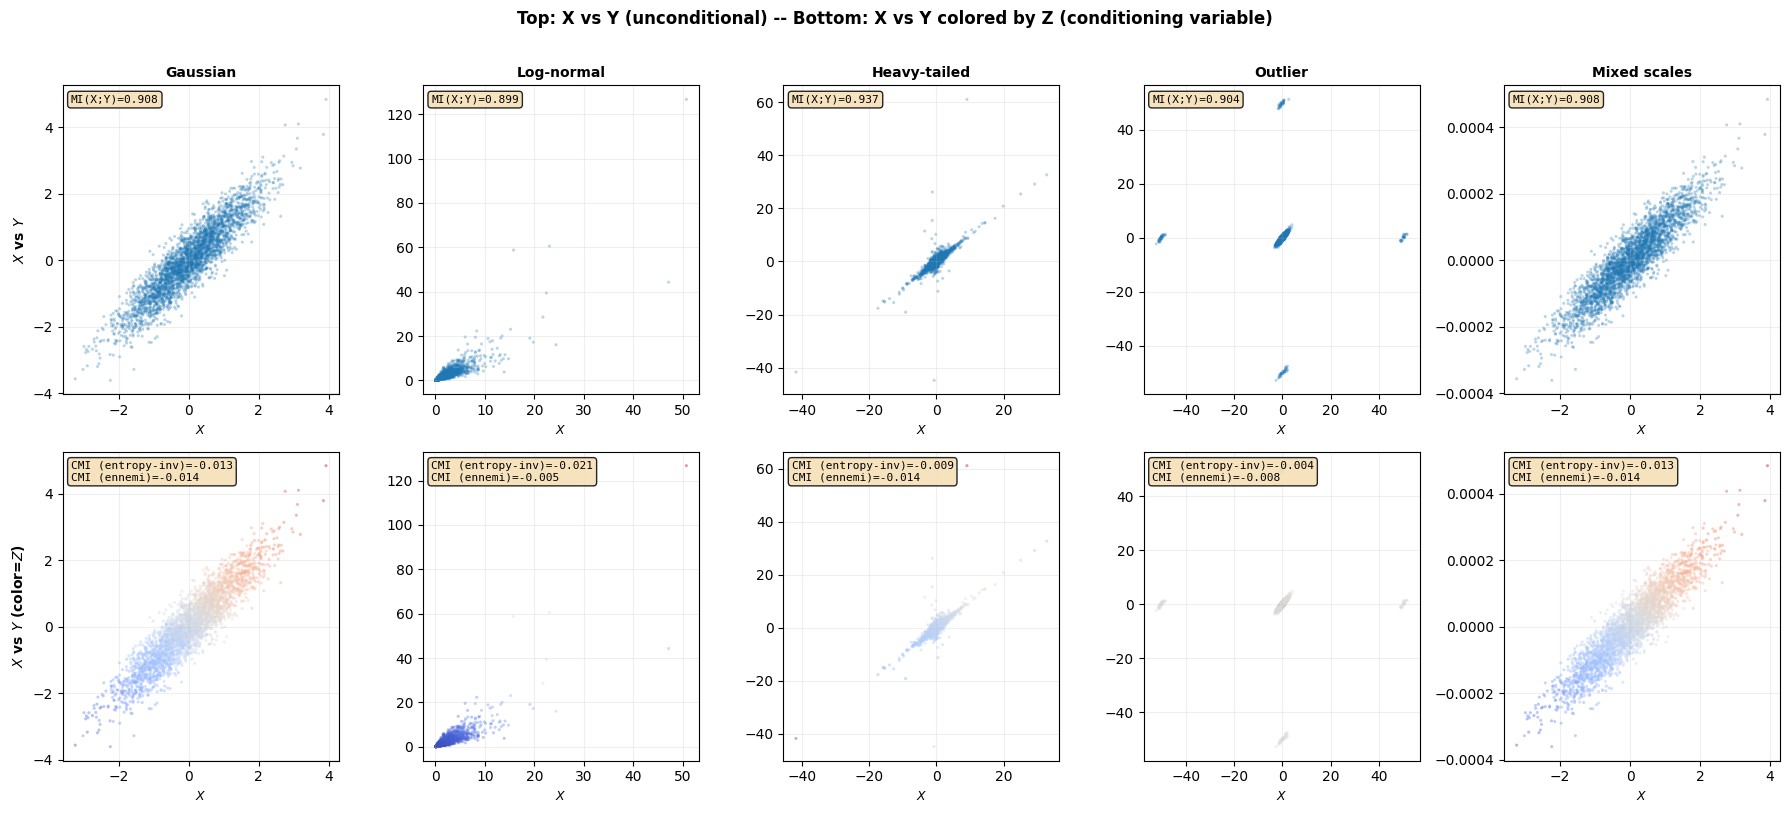

In [11]:
fig, axes = plt.subplots(2, len(pathologies), figsize=(18, 8))

for col, (name, (x, y, z)) in enumerate(pathologies.items()):
    label = name.split("\n")[0]

    ax = axes[0, col]
    ax.scatter(x, y, s=5, alpha=0.3, edgecolor="none")
    ax.set_title(label, fontsize=10, fontweight="bold")
    if col == 0:
        ax.set_ylabel("$X$ vs $Y$", fontsize=10, fontweight="bold")
    ax.set_xlabel("$X$", fontsize=9)

    text = f"MI(X;Y)={mi_ei(x,y):.3f}"
    ax.annotate(text, xy=(0.03, 0.97), xycoords="axes fraction",
                verticalalignment="top", fontsize=8, family="monospace",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.85))
    ax.grid(True, alpha=0.2)

    ax2 = axes[1, col]
    sc = ax2.scatter(x, y, c=z, s=5, alpha=0.4, edgecolor="none", cmap="coolwarm")
    if col == 0:
        ax2.set_ylabel("$X$ vs $Y$ (color=$Z$)", fontsize=10, fontweight="bold")
    ax2.set_xlabel("$X$", fontsize=9)

    text = (f"CMI (entropy-inv)={cmi_ei_path[col]:.3f}\n"
            f"CMI (ennemi)={cmi_ennemi_path[col]:.3f}")
    ax2.annotate(text, xy=(0.03, 0.97), xycoords="axes fraction",
                 verticalalignment="top", fontsize=8, family="monospace",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.85))
    ax2.grid(True, alpha=0.2)

fig.suptitle("Top: X vs Y (unconditional) -- Bottom: X vs Y colored by Z (conditioning variable)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 6. Increasing Outlier Contamination: CMI Robustness

Fork structure ($Z \to X$, $Z \to Y$) where CMI should be ~0, with increasing fractions
of injected outliers.


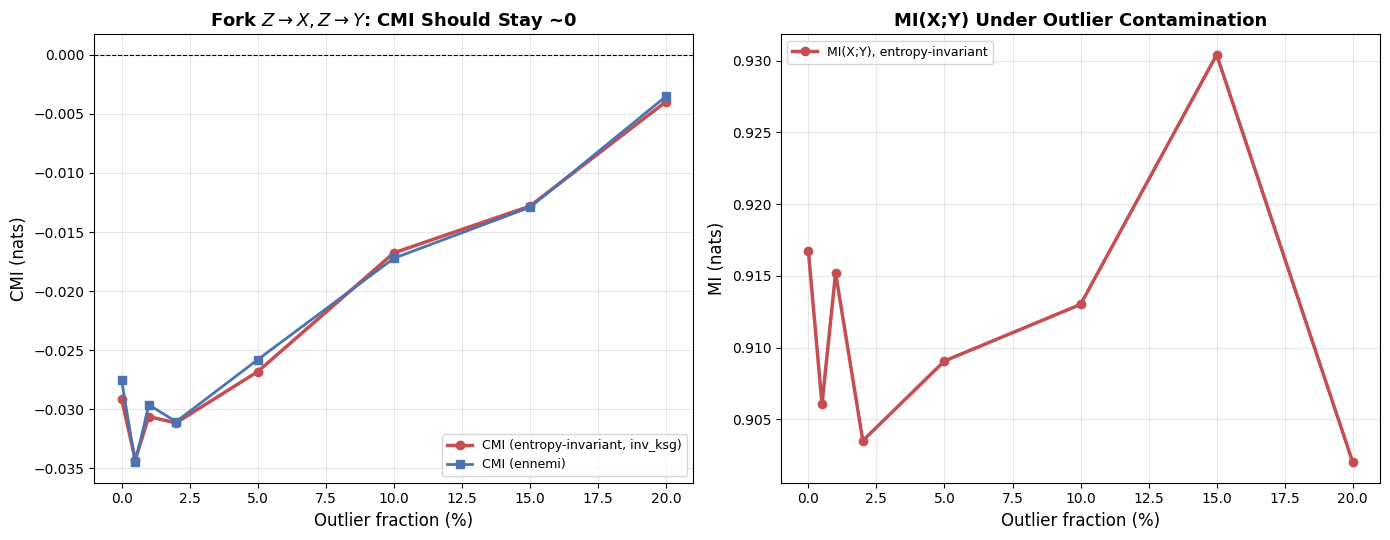

At 20% outliers: CMI (entropy-inv) = -0.0040,  CMI (ennemi) = -0.0035


In [12]:
np.random.seed(42)
n = 3000

z_clean = np.random.randn(n)
x_clean = z_clean + 0.3 * np.random.randn(n)
y_clean = z_clean + 0.3 * np.random.randn(n)

outlier_fracs = [0, 0.005, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20]
cmi_ei_sweep = []
cmi_ennemi_sweep = []
mi_ei_sweep = []

for frac in outlier_fracs:
    x, y, z = x_clean.copy(), y_clean.copy(), z_clean.copy()
    n_spikes = int(frac * n)
    if n_spikes > 0:
        for arr in [x, y, z]:
            idx = np.random.choice(n, n_spikes, replace=False)
            arr[idx] += 50 * np.random.choice([-1, 1], size=n_spikes)

    cmi_ei_sweep.append(cmi_ei(x, y, z))
    cmi_ennemi_sweep.append(ennemi.estimate_mi(y, x, cond=z, k=3)[0, 0])
    mi_ei_sweep.append(mi_ei(x, y))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
pct = [f * 100 for f in outlier_fracs]

ax = axes[0]
ax.plot(pct, cmi_ei_sweep, "o-", label="CMI (entropy-invariant, inv_ksg)", color="#C44E52", linewidth=2.5)
ax.plot(pct, cmi_ennemi_sweep, "s-", label="CMI (ennemi)", color="#4C72B0", linewidth=2)
ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Outlier fraction (%)", fontsize=12)
ax.set_ylabel("CMI (nats)", fontsize=12)
ax.set_title("Fork $Z{\\to}X, Z{\\to}Y$: CMI Should Stay ~0", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(pct, mi_ei_sweep, "o-", label="MI(X;Y), entropy-invariant", color="#C44E52", linewidth=2.5)
ax2.set_xlabel("Outlier fraction (%)", fontsize=12)
ax2.set_ylabel("MI (nats)", fontsize=12)
ax2.set_title("MI(X;Y) Under Outlier Contamination", fontsize=13, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"At 20% outliers: CMI (entropy-inv) = {cmi_ei_sweep[-1]:.4f},  CMI (ennemi) = {cmi_ennemi_sweep[-1]:.4f}")


## 7. The Sharpest Test: A Few Extreme Points, Not a Fraction

Section 4 and section 6 varied the *fraction* of contaminated points (2%-20%) with
moderate-magnitude spikes, and both packages tracked each other closely throughout. That's
not actually the scenario where the invariant measure should have an edge -- once both
packages use a shared-radius KSG/Frenzel-Pompe estimator, MI/CMI is close to invariant
under *moderate* per-variable rescaling regardless of which constant you divide by. Both
`ennemi` and `entropy-invariant` do normalize (`ennemi` divides by `std`, confirmed by
reading `ennemi._driver._rescale_data`; `entropy-invariant` divides by the invariant
measure `r_X`) -- **`sklearn` is the one that does no normalization at all** for
continuous-continuous MI, confirmed earlier by reading `_compute_mi_cc`.

The scenario that *does* expose the std-vs-invariant gap is different: **a tiny number of
extreme values**, not a moderate fraction of moderate spikes. `std` is a variance-based
statistic -- a single sufficiently extreme point can dominate it completely. `r_X`
(median nearest-neighbor distance) barely notices a handful of extreme points, no matter
how extreme, because the median is robust by construction.


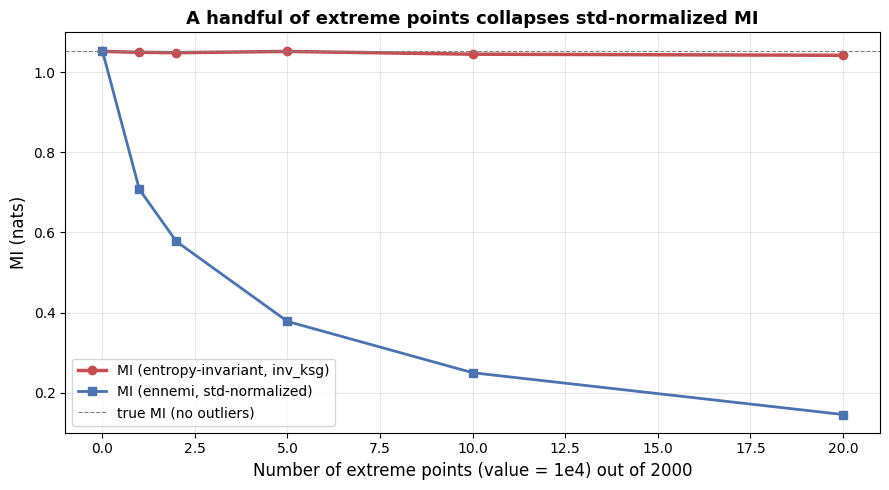

# outliers     MI (entropy-inv)    MI (ennemi)
----------------------------------------------
0                        1.0517         1.0538
1                        1.0493         0.7074
2                        1.0485         0.5773
5                        1.0515         0.3778
10                       1.0447         0.2498
20                       1.0420         0.1455


In [13]:
# X ~ N(0,1), Y = 0.8*X + noise (true MI is stable, ~1.05 nats).
# Inject a SMALL NUMBER of EXTREME points into X (not a fraction of moderate spikes)
# and watch what happens to std-normalized vs invariant-measure-normalized MI.
np.random.seed(0)
n = 2000
x_clean = np.random.randn(n)
y_mi = 0.8 * x_clean + 0.3 * np.random.randn(n)

n_outliers_list = [0, 1, 2, 5, 10, 20]
mi_ei_extreme = []
mi_ennemi_extreme = []

for n_out in n_outliers_list:
    x = x_clean.copy()
    if n_out > 0:
        idx = np.random.choice(n, n_out, replace=False)
        x[idx] = 1e4  # extreme, but just a handful of points out of 2000
    mi_ei_extreme.append(mi_ei(x, y_mi))
    mi_ennemi_extreme.append(ennemi.estimate_mi(y_mi, x, k=3)[0, 0])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_outliers_list, mi_ei_extreme, "o-", label="MI (entropy-invariant, inv_ksg)", color="#C44E52", linewidth=2.5)
ax.plot(n_outliers_list, mi_ennemi_extreme, "s-", label="MI (ennemi, std-normalized)", color="#4C72B0", linewidth=2)
ax.axhline(y=mi_ei_extreme[0], color="gray", linewidth=0.8, linestyle="--", label="true MI (no outliers)")
ax.set_xlabel("Number of extreme points (value = 1e4) out of 2000", fontsize=12)
ax.set_ylabel("MI (nats)", fontsize=12)
ax.set_title("A handful of extreme points collapses std-normalized MI", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'# outliers':<12} {'MI (entropy-inv)':>18} {'MI (ennemi)':>14}")
print("-" * 46)
for n_out, ei, en in zip(n_outliers_list, mi_ei_extreme, mi_ennemi_extreme):
    print(f"{n_out:<12} {ei:>18.4f} {en:>14.4f}")


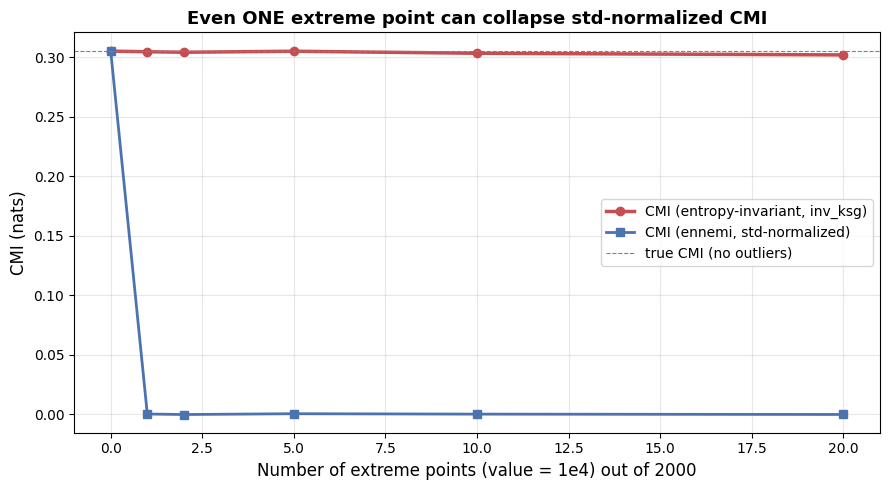

# outliers    CMI (entropy-inv)   CMI (ennemi)
----------------------------------------------
0                        0.3051         0.3056
1                        0.3046         0.0003
2                        0.3042        -0.0002
5                        0.3051         0.0005
10                       0.3033         0.0002
20                       0.3020        -0.0001


In [14]:
# Same idea for CMI: a direct X->Y link on top of a confounder Z, so the true CMI
# is large (~0.3 nats) and should stay large regardless of a few extreme points in X.
np.random.seed(0)
n = 2000
z_cmi = np.random.randn(n)
x_clean_cmi = z_cmi + 0.3 * np.random.randn(n)
y_cmi = 0.9 * x_clean_cmi + z_cmi + 0.3 * np.random.randn(n)

cmi_ei_extreme = []
cmi_ennemi_extreme = []

for n_out in n_outliers_list:
    x = x_clean_cmi.copy()
    if n_out > 0:
        idx = np.random.choice(n, n_out, replace=False)
        x[idx] = 1e4
    cmi_ei_extreme.append(cmi_ei(x, y_cmi, z_cmi))
    cmi_ennemi_extreme.append(ennemi.estimate_mi(y_cmi, x, cond=z_cmi, k=3)[0, 0])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_outliers_list, cmi_ei_extreme, "o-", label="CMI (entropy-invariant, inv_ksg)", color="#C44E52", linewidth=2.5)
ax.plot(n_outliers_list, cmi_ennemi_extreme, "s-", label="CMI (ennemi, std-normalized)", color="#4C72B0", linewidth=2)
ax.axhline(y=cmi_ei_extreme[0], color="gray", linewidth=0.8, linestyle="--", label="true CMI (no outliers)")
ax.set_xlabel("Number of extreme points (value = 1e4) out of 2000", fontsize=12)
ax.set_ylabel("CMI (nats)", fontsize=12)
ax.set_title("Even ONE extreme point can collapse std-normalized CMI", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'# outliers':<12} {'CMI (entropy-inv)':>18} {'CMI (ennemi)':>14}")
print("-" * 46)
for n_out, ei, en in zip(n_outliers_list, cmi_ei_extreme, cmi_ennemi_extreme):
    print(f"{n_out:<12} {ei:>18.4f} {en:>14.4f}")


In [15]:
# Why: std is dominated by the few extreme points; r_X (median-based) barely moves.
from entropy_invariant.helpers.computation import compute_invariant_measure

x_5out = x_clean.copy()
idx = np.random.default_rng(0).choice(n, 5, replace=False)
x_5out[idx] = 1e4

std_x = np.std(x_5out)
r_x = compute_invariant_measure(x_5out)
print(f"With 5 extreme points out of {n}:")
print(f"  std(x) = {std_x:8.2f}   (inflated by the outliers)")
print(f"  r_X(x) = {r_x:8.4f}    (median-based, barely moved)")
print()
print(f"Dividing by std shrinks the well-behaved bulk's spacing by ~{std_x:.0f}x relative")
print("to Y's untouched normalization -- in the joint KSG search this recreates the same")
print("'one variable becomes numerically invisible' failure mode as an explicit extreme")
print("scale mismatch (see plot_dependency_measures_comparison.ipynb), except here it's")
print("self-inflicted by std-normalizing outlier-contaminated data.")


With 5 extreme points out of 2000:
  std(x) =   499.38   (inflated by the outliers)
  r_X(x) =   1.3407    (median-based, barely moved)

Dividing by std shrinks the well-behaved bulk's spacing by ~499x relative
to Y's untouched normalization -- in the joint KSG search this recreates the same
'one variable becomes numerically invisible' failure mode as an explicit extreme
scale mismatch (see plot_dependency_measures_comparison.ipynb), except here it's
self-inflicted by std-normalizing outlier-contaminated data.


**Takeaway**: the invariant measure's practical advantage over `std` for MI/CMI isn't
about moderate skew, moderate outlier fractions, or non-linear confounding -- KSG's
shared-radius counting already tolerates all of those well under either normalization
(sections 1, 4, 6, 8). It's specifically about **a small number of extreme values**
contaminating otherwise well-behaved data -- sensor glitches, data-entry errors, rare
extreme events -- which is a realistic failure mode and exactly the regime where `std` is
a known-fragile statistic and the median-based invariant measure is not.


## 8. Non-linear Confounding: Sine Relationship

A harder test: the confounding relationship is **non-linear**.

$Z \sim \text{Uniform}(0, 1)$, $X = \sin(4\pi Z) + \varepsilon_1$, $Y = \cos(4\pi Z) + \varepsilon_2$

$X$ and $Y$ are dependent only through $Z$, but the relationship is non-linear. CMI
should stay ~0 if the estimator properly accounts for the non-linear confounding.


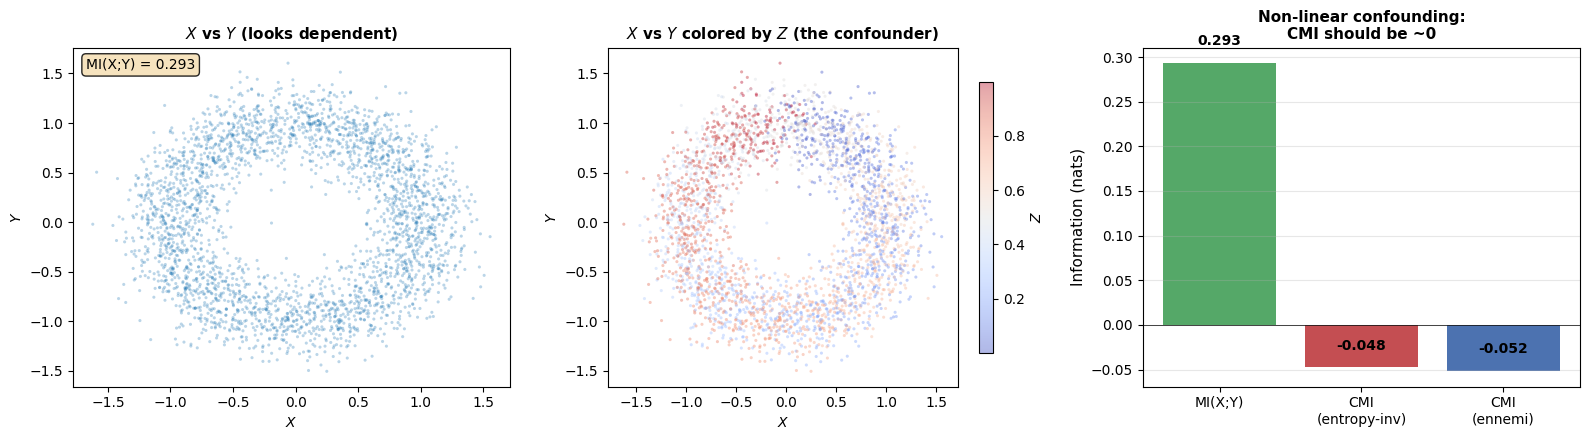

In [16]:
np.random.seed(42)
n = 3000

z_nl = np.random.rand(n)
x_nl = np.sin(4 * np.pi * z_nl) + 0.2 * np.random.randn(n)
y_nl = np.cos(4 * np.pi * z_nl) + 0.2 * np.random.randn(n)

mi_xy = mi_ei(x_nl, y_nl)
cmi_i = cmi_ei(x_nl, y_nl, z_nl)
cmi_e = ennemi.estimate_mi(y_nl, x_nl, cond=z_nl, k=3)[0, 0]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(x_nl, y_nl, s=5, alpha=0.3, edgecolor="none")
axes[0].set_xlabel("$X$"); axes[0].set_ylabel("$Y$")
axes[0].set_title("$X$ vs $Y$ (looks dependent)", fontsize=11, fontweight="bold")
axes[0].annotate(f"MI(X;Y) = {mi_xy:.3f}", xy=(0.03, 0.97), xycoords="axes fraction",
                 verticalalignment="top", fontsize=10,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.85))

sc = axes[1].scatter(x_nl, y_nl, c=z_nl, s=5, alpha=0.4, edgecolor="none", cmap="coolwarm")
axes[1].set_xlabel("$X$"); axes[1].set_ylabel("$Y$")
axes[1].set_title("$X$ vs $Y$ colored by $Z$ (the confounder)", fontsize=11, fontweight="bold")
plt.colorbar(sc, ax=axes[1], label="$Z$", shrink=0.8)

bars = axes[2].bar(["MI(X;Y)", "CMI\n(entropy-inv)", "CMI\n(ennemi)"],
                    [mi_xy, cmi_i, cmi_e],
                    color=["#55A868", "#C44E52", "#4C72B0"])
axes[2].axhline(y=0, color="black", linewidth=0.5)
axes[2].set_ylabel("Information (nats)", fontsize=11)
axes[2].set_title("Non-linear confounding:\nCMI should be ~0", fontsize=11, fontweight="bold")
axes[2].grid(True, alpha=0.3, axis="y")

for bar, val in zip(bars, [mi_xy, cmi_i, cmi_e]):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


## 9. Feature Selection with CMI

A practical application: given features $x_1, x_2, x_3$ and target $y$, use CMI to find
which features provide **additional** information beyond what's already selected.

$y = x_1 + \sin(4\pi x_2) + 0.1\varepsilon$, $x_3$ = noise, $x_1$ and $x_2$ are
independent.

Note: each step below only tests features *not yet selected* against the conditioning
set -- conditioning a feature on itself (`CMI(xi; y | xi)`) is undefined/degenerate
(it's always exactly 0 by definition, and no k-NN CMI estimator handles that
self-conditioning edge case gracefully), so it's deliberately excluded from every step.


In [17]:
np.random.seed(42)
n = 3000

x1 = np.random.rand(n)
x2 = np.random.rand(n)
x3 = np.random.rand(n)  # irrelevant
y_fs = x1 + np.sin(4 * np.pi * x2) + 0.1 * np.random.randn(n)

print("=== Step 1: MI with target (select first feature) ===")
for name, feat in [("x1 (linear)", x1), ("x2 (non-linear)", x2), ("x3 (noise)", x3)]:
    mi_i = mi_ei(feat, y_fs)
    mi_e = ennemi.estimate_mi(y_fs, feat, k=3)[0, 0]
    print(f"  MI({name}, y):  entropy-inv={mi_i:.4f}  ennemi={mi_e:.4f}")

# x2 has the highest MI -> selected first. Use CMI to find what adds info beyond it.
print("\n=== Step 2: CMI given x2 already selected ===")
print("  I(xi; y | x2) -- additional information beyond x2 (xi != x2):")
for name, feat in [("x1 (linear)", x1), ("x3 (noise)", x3)]:
    cmi_i = cmi_ei(feat, y_fs, x2)
    cmi_e = ennemi.estimate_mi(y_fs, feat, cond=x2, k=3)[0, 0]
    print(f"  CMI({name}, y | x2):  entropy-inv={cmi_i:.4f}  ennemi={cmi_e:.4f}")

print("\n=== Step 3: CMI given x1 already selected ===")
print("  I(xi; y | x1) -- additional information beyond x1 (xi != x1):")
for name, feat in [("x2 (non-linear)", x2), ("x3 (noise)", x3)]:
    cmi_i = cmi_ei(feat, y_fs, x1)
    cmi_e = ennemi.estimate_mi(y_fs, feat, cond=x1, k=3)[0, 0]
    print(f"  CMI({name}, y | x1):  entropy-inv={cmi_i:.4f}  ennemi={cmi_e:.4f}")


=== Step 1: MI with target (select first feature) ===
  MI(x1 (linear), y):  entropy-inv=0.2851  ennemi=0.2839
  MI(x2 (non-linear), y):  entropy-inv=0.8938  ennemi=0.8953
  MI(x3 (noise), y):  entropy-inv=0.0012  ennemi=0.0013

=== Step 2: CMI given x2 already selected ===
  I(xi; y | x2) -- additional information beyond x2 (xi != x2):
  CMI(x1 (linear), y | x2):  entropy-inv=0.8170  ennemi=0.7978


  CMI(x3 (noise), y | x2):  entropy-inv=0.0271  ennemi=0.0275

=== Step 3: CMI given x1 already selected ===
  I(xi; y | x1) -- additional information beyond x1 (xi != x1):
  CMI(x2 (non-linear), y | x1):  entropy-inv=1.3824  ennemi=1.3577
  CMI(x3 (noise), y | x1):  entropy-inv=0.0129  ennemi=0.0141


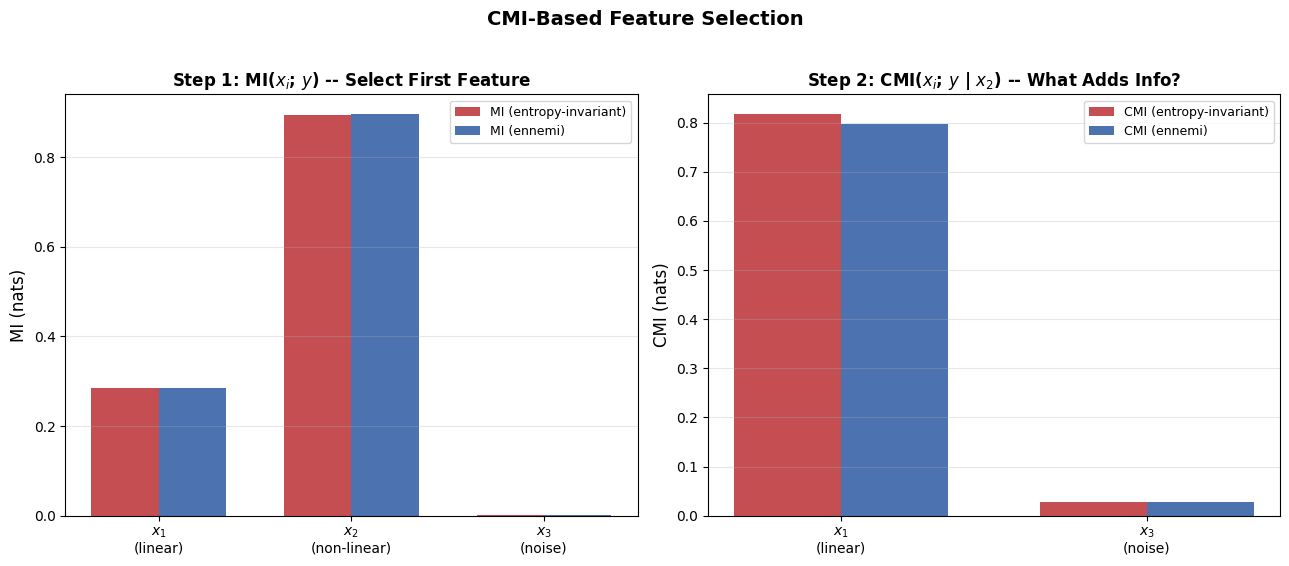

In [18]:
# Visualize the feature selection process.
# Step-2/Step-3 panels only include the two features NOT used as the conditioning
# variable (see the note above on why self-conditioning is excluded).
features_all = ["$x_1$\n(linear)", "$x_2$\n(non-linear)", "$x_3$\n(noise)"]
feats_all = [x1, x2, x3]

mi_ei_fs = [mi_ei(f, y_fs) for f in feats_all]
mi_enn_fs = [ennemi.estimate_mi(y_fs, f, k=3)[0, 0] for f in feats_all]

# CMI given x2 (highest-MI feature), only for x1 and x3
cond_x2_labels = ["$x_1$\n(linear)", "$x_3$\n(noise)"]
cmi_ei_given_x2 = [cmi_ei(f, y_fs, x2) for f in [x1, x3]]
cmi_enn_given_x2 = [ennemi.estimate_mi(y_fs, f, cond=x2, k=3)[0, 0] for f in [x1, x3]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

x_pos_all = np.arange(3)
width = 0.35

ax = axes[0]
ax.bar(x_pos_all - width/2, mi_ei_fs, width, label="MI (entropy-invariant)", color="#C44E52")
ax.bar(x_pos_all + width/2, mi_enn_fs, width, label="MI (ennemi)", color="#4C72B0")
ax.set_xticks(x_pos_all)
ax.set_xticklabels(features_all, fontsize=10)
ax.set_ylabel("MI (nats)", fontsize=12)
ax.set_title("Step 1: MI($x_i$; $y$) -- Select First Feature", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")

x_pos_cond = np.arange(2)
ax2 = axes[1]
ax2.bar(x_pos_cond - width/2, cmi_ei_given_x2, width, label="CMI (entropy-invariant)", color="#C44E52")
ax2.bar(x_pos_cond + width/2, cmi_enn_given_x2, width, label="CMI (ennemi)", color="#4C72B0")
ax2.set_xticks(x_pos_cond)
ax2.set_xticklabels(cond_x2_labels, fontsize=10)
ax2.set_ylabel("CMI (nats)", fontsize=12)
ax2.set_title("Step 2: CMI($x_i$; $y$ | $x_2$) -- What Adds Info?", fontsize=12, fontweight="bold")
ax2.axhline(y=0, color="black", linewidth=0.5)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis="y")

fig.suptitle("CMI-Based Feature Selection", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## Summary

### What sklearn is missing

**sklearn has no CMI function.** It only provides `mutual_info_regression` and
`mutual_info_classif` -- no conditioning variable support. For CMI, you need a separate
package like `ennemi` or `entropy-invariant`.

### `entropy-invariant` (`inv_ksg`, default) vs `ennemi`

| | entropy-invariant | ennemi |
|---|---|---|
| **CMI** | `conditional_mutual_information(X, Y, Z)` | `estimate_mi(y, x, cond=z)` |
| **Algorithm** | KSG / Frenzel-Pompe (shared-radius neighbor counting) | KSG / Frenzel-Pompe (same family) |
| **Preprocessing** | Invariant measure (median nn-dist) | Std normalization |
| **Causal structures** | Correct on all four | Correct on all four |
| **Moderate skew / heavy tails / outlier fraction** | Tracks ennemi closely (sections 1, 4, 6) | Reference behavior |
| **A few extreme values (section 7)** | Stable -- median-based `r_X` barely moves | Can collapse badly -- `std` is dominated by the extreme points |
| **Affine scale invariance** | Yes, including asymmetric per-variable scale mismatch | No -- relies on `std`, breaks under extreme asymmetric scale mismatch |
| **Bonus** | Also provides MI, NMI, interaction info, PID, CMI matrix | Also provides time-lagged MI |

**Takeaway**: both packages use the same *kind* of algorithm (shared-radius KSG/Frenzel-
Pompe), so for moderate pathologies -- skew, heavy tails, non-linear confounding, a
*fraction* of moderate-magnitude outliers, causal structure recovery -- they agree
closely (sections 1-6, 8-9). That similarity is genuine, not a wash: it confirms MI/CMI
computed this way is fairly insensitive to *which* reasonable per-variable normalization
you use. Where they diverge sharply is a **small number of extreme values** (section 7):
`std` is a variance-based statistic that a single sufficiently extreme point can dominate,
while the invariant measure's median-based construction barely notices it. That's the
practical scenario -- not moderate pathologies -- where `entropy-invariant`'s
normalization has a real, demonstrable edge over `ennemi`'s `std`-based one. The other
structural advantage is exact affine invariance (rescale or shift any variable
independently, results don't move at all), which `ennemi` doesn't have by construction
even before outliers enter the picture (see `plot_dependency_measures_comparison.ipynb`
for the asymmetric-scale-mismatch case).
